# M66 Pre-Final Scenario Implementation — High-Demand and Reduced-Service

**Scope owner:** Kawol — Scenario Implementation (High-Demand and Reduced-Service operating conditions)

**Branch:** `feature/prefinal-scenarios` (created from `main`)

**Revision 2** — this notebook incorporates group review feedback on the first draft. See Section 21 ("Changelog") for a full list of what changed in this revision and why.

This notebook builds on the completed Midterm work in `m66_baseline_simulation.ipynb` and implements the two Pre-Final stress-test scenarios listed as "Planned" in the project README:

- **High-Demand scenario** — passenger demand increased by 40%, published GTFS reference service unchanged. The original Baseline passenger arrivals are preserved exactly; only the additional passengers needed to reach +40% are newly generated.
- **Reduced-Service scenario** — passenger demand unchanged, exactly one scheduled trip removed from every study hour, using the trip whose Stop 6 arrival time is closest to that hour's midpoint (earlier trip wins ties).

**Design rule followed throughout:** no separate simulation engine is built. The discrete-event engine (`handle_passenger_arrival`, `handle_bus_arrival`, `run_service_simulation`) is reused from the baseline notebook, with one documented extension: it now also returns a per-stop results table and explicit waiting-time/occupancy validity flags (Section 9). No queueing, boarding, alighting, or capacity rule was changed.

| Scenario | Passenger streams | Service schedule / occupancy / alighting |
|---|---|---|
| Baseline | Baseline demand | Baseline GTFS |
| High-Demand | Baseline passengers (unchanged) + newly generated additional passengers for the +40% delta | Baseline GTFS (unchanged) |
| Reduced-Service | Baseline demand (same streams as Baseline) | GTFS with 1 trip removed per hour (recomputed occupancy/alighting) |

Each scenario starts at 30 replications and automatically extends by 10 (up to 50) if the required 95% confidence-interval precision is not met (Section 13). The Combined scenario and GA re-optimization under these conditions remain **out of scope** for this handoff — see Section 22 (Scope Boundary).


In [1]:
# DATA SOURCES
# MTA Bus Stop Level Ridership: Beginning 2024
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS
# https://www.mta.info/developers
#
# GTFS Schedule Reference
# https://gtfs.org/documentation/schedule/reference/
#
# DEVELOPMENT AND DOCUMENTATION NOTE
# This notebook reuses the data-loading, GTFS-parsing, occupancy/alighting,
# and discrete-event simulation code from m66_baseline_simulation.ipynb.
# Sections that are copied unmodified from the baseline notebook are marked
# "(reused, unmodified)" in their heading. Sections that generalize or extend
# a baseline function so it accepts scenario inputs as parameters (instead of
# hardcoded notebook globals), or add new return values, are marked
# "(generalized/extended from baseline)" and the exact change is documented
# in-line. New scenario logic (demand composition, deterministic trip
# removal, precision-check replication control, validation) is written for
# this handoff and documented with its own references.
#
# AI-assisted suggestions were used as a starting point for some Python code,
# following the same practice already documented in the baseline notebook.
# The code was adapted to the scenario requirements, run against the actual
# project data, and checked against the baseline results before handoff.


In [2]:
# Import the libraries used for data handling, simulation, statistics, and
# plotting.
from pathlib import Path
import heapq

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


## 1. Setup and Shared Configuration

In [3]:
# Define the main project directories and input file locations.
# Identical to the baseline notebook so this notebook can be run from the
# same `MODESIM_Project/code/` working directory.
project_dir = Path("..")

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
gtfs_dir = raw_dir / "gtfs_m"

figures_dir = project_dir / "output" / "figures"
tables_dir = project_dir / "output" / "tables"

clean_file = processed_dir / "MTA_M66_Selected_Stops_2025_CLEAN.csv"
raw_file = raw_dir / "MTA_M66_Eastbound_2025_RAW.csv"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

required_inputs = [
    clean_file,
    raw_file,
    gtfs_dir / "trips.txt",
    gtfs_dir / "stop_times.txt",
]

missing_inputs = [path for path in required_inputs if not path.exists()]

if missing_inputs:
    missing_list = "\n".join(f"- {path}" for path in missing_inputs)
    raise FileNotFoundError(
        "Required simulation input files are missing:\n"
        f"{missing_list}"
    )

print("All required inputs found.")


All required inputs found.


In [4]:
# Shared simulation configuration. These values are identical to the
# baseline notebook so both scenarios stay directly comparable to Baseline.
bus_capacity = 60

morning_hours = [6, 7, 8, 9, 10]
evening_hours = [15, 16, 17, 18, 19]
study_hours = morning_hours + evening_hours

selected_stops = [6, 7, 8, 9, 10]

master_seed = 2026

# --- Pre-Final scenario parameters ---

# High-Demand scenario: +40% passenger demand.
demand_growth_factor = 1.40

# Reduced-Service scenario: exactly one trip removed per study hour, using a
# deterministic closest-to-midpoint rule (defined and applied in Section 5).
trips_removed_per_hour = 1

# Replication precision control (same 95% confidence-interval approach as
# the baseline notebook, Section 13): start at 30 replications; if the
# required precision on Mean Completed Wait or Peak Queue is not met for
# either period, add 10 more replications and recheck, up to 50 total.
precision_start_replications = 30
precision_increment = 10
precision_max_replications = 50
precision_confidence_level = 0.95


## 2. Load Baseline Passenger Demand (reused, unmodified)

In [5]:
# Reference: pandas.read_csv()
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
#
# Identical to m66_baseline_simulation.ipynb Section 1.

df = pd.read_csv(clean_file)

df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Hour"]).dt.hour

print("Cleaned rows:", len(df))
print("Study hours:", sorted(df["Hour"].unique()))
print("Selected stops:", sorted(df["Stop Sequence"].unique()))


Cleaned rows: 12814
Study hours: [np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]
Selected stops: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [6]:
# Reference: pandas DataFrame.groupby()
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
#
# Representative mean Boardings/Alightings by stop-hour, and the baseline
# whole-number Passenger Count used by the simulation. Identical rounding
# rule as the baseline notebook: max(0, floor(p + 0.5)).

demand_table = (
    df.groupby(["Stop Sequence", "Stop Name", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
    .sort_values(["Stop Sequence", "Hour"])
    .reset_index(drop=True)
)

baseline_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

baseline_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(baseline_demand["Boardings"] + 0.5)
).astype(int)

print("Baseline passenger total per replication:", baseline_demand["Passenger Count"].sum())
baseline_demand.head(10)


Baseline passenger total per replication: 776


,Stop Sequence,Stop Name,Hour,Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,8
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,25
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,40
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,24
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,19
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,34
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,28
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,31
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,22
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,11


## 3. High-Demand Scenario — +40% Passenger Demand, Baseline Passengers Preserved

**What changes from Baseline:** the representative mean Boardings at every stop-hour is scaled by `demand_growth_factor = 1.40` *before* the same deterministic whole-passenger rounding rule already used in Baseline is applied. The demand structure (Stop Sequence, Stop Name, Hour) is unchanged — only the passenger count per stop-hour grows. (This calculation itself was confirmed correct in review and is unchanged from the first draft.)

**Revision note (passenger-stream composition):** the first draft regenerated the *entire* High-Demand passenger stream from the scaled counts using the same seed as Baseline. That does not keep the Baseline passengers themselves identical between scenarios — the whole stream shifts once the per-cell counts change, even though the same seed is used. This revision instead:

1. Computes an **Additional Passenger Count** per stop-hour cell = `High-Demand Passenger Count − Baseline Passenger Count` (always ≥ 0, since scaling by 1.40 before rounding can only raise or hold each cell's count — see the assertion below).
2. Generates the Baseline portion of each High-Demand replication using the **exact same code and seed** as the official Baseline stream, so those arrivals are byte-for-byte identical between Baseline and High-Demand.
3. Generates only the **additional** passengers using a distinct, deterministic sub-stream (Section 11), and concatenates the two into the full High-Demand passenger set for that replication.

Reference: NumPy floor() — https://numpy.org/doc/stable/reference/generated/numpy.floor.html


In [7]:
high_demand_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

high_demand_demand["Scaled Boardings"] = (
    high_demand_demand["Boardings"] * demand_growth_factor
)

high_demand_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(high_demand_demand["Scaled Boardings"] + 0.5)
).astype(int)

baseline_total = baseline_demand["Passenger Count"].sum()
high_demand_total = high_demand_demand["Passenger Count"].sum()

print("Baseline passenger total per replication:   ", baseline_total)
print("High-Demand passenger total per replication:", high_demand_total)
print(
    "Realized growth (differs slightly from 1.40 only due to",
    "whole-passenger rounding at each stop-hour cell):",
    round(high_demand_total / baseline_total, 4)
)

high_demand_demand.head(10)


Baseline passenger total per replication:    776
High-Demand passenger total per replication: 1083
Realized growth (differs slightly from 1.40 only due to whole-passenger rounding at each stop-hour cell): 1.3956


,Stop Sequence,Stop Name,Hour,Boardings,Scaled Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,10.560630,11
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,35.540541,36
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,56.551351,57
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,33.827907,34
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,26.556250,27
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,47.156757,47
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,39.243243,39
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,43.904215,44
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,30.800000,31
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,15.842688,16


In [8]:
# Additional Passenger Count per stop-hour cell — this is the ONLY part of
# High-Demand demand that gets newly generated passengers (Section 11). The
# Baseline-matching portion is generated separately using the unchanged
# Baseline demand table above.
additional_demand = baseline_demand[
    ["Stop Sequence", "Stop Name", "Hour", "Passenger Count"]
].rename(columns={"Passenger Count": "Baseline Passenger Count"}).merge(
    high_demand_demand[
        ["Stop Sequence", "Stop Name", "Hour", "Passenger Count"]
    ].rename(columns={"Passenger Count": "High-Demand Passenger Count"}),
    on=["Stop Sequence", "Stop Name", "Hour"]
)

additional_demand["Additional Passenger Count"] = (
    additional_demand["High-Demand Passenger Count"]
    - additional_demand["Baseline Passenger Count"]
)

assert (additional_demand["Additional Passenger Count"] >= 0).all(), (
    "Every stop-hour cell's High-Demand count must be >= its Baseline count."
)

print("Additional passengers to generate per replication:", additional_demand["Additional Passenger Count"].sum())
additional_demand.head(10)


Additional passengers to generate per replication: 307


,Stop Sequence,Stop Name,Hour,Baseline Passenger Count,High-Demand Passenger Count,Additional Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,8,11,3
1,6,W 65 ST/CENTRAL PARK WEST,7,25,36,11
2,6,W 65 ST/CENTRAL PARK WEST,8,40,57,17
3,6,W 65 ST/CENTRAL PARK WEST,9,24,34,10
4,6,W 65 ST/CENTRAL PARK WEST,10,19,27,8
5,6,W 65 ST/CENTRAL PARK WEST,15,34,47,13
6,6,W 65 ST/CENTRAL PARK WEST,16,28,39,11
7,6,W 65 ST/CENTRAL PARK WEST,17,31,44,13
8,6,W 65 ST/CENTRAL PARK WEST,18,22,31,9
9,6,W 65 ST/CENTRAL PARK WEST,19,11,16,5


## 4. Load the Baseline GTFS Reference Service (reused, unmodified)

In [9]:
# Identical to m66_baseline_simulation.ipynb Section 2.
trips = pd.read_csv(gtfs_dir / "trips.txt")
stop_times = pd.read_csv(gtfs_dir / "stop_times.txt")

m66_trips = trips[
    (trips["route_id"] == "M66")
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (trips["direction_id"] == 0)
    & (trips["shape_id"] == "M660030")
].copy()

print("Full-route weekday trips:", len(m66_trips))


Full-route weekday trips: 138


In [10]:
selected_stop_times = stop_times[
    stop_times["trip_id"].isin(m66_trips["trip_id"])
    & stop_times["stop_sequence"].between(6, 10)
].copy()

first_stop_times = selected_stop_times[
    selected_stop_times["stop_sequence"] == 6
].copy()

first_stop_times["Hour"] = (
    first_stop_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

study_trip_ids = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
]["trip_id"]

study_stop_times = selected_stop_times[
    selected_stop_times["trip_id"].isin(study_trip_ids)
].copy()

def time_to_minutes(time_text):
    hours, minutes, seconds = map(int, time_text.split(":"))
    return (hours * 60) + minutes + (seconds / 60)

study_stop_times["arrival_minutes"] = (
    study_stop_times["arrival_time"].apply(time_to_minutes)
)

# Also needed for the closest-to-midpoint trip-removal rule (Section 5).
first_stop_times["Arrival Minutes"] = (
    first_stop_times["arrival_time"].apply(time_to_minutes)
)

trips_per_hour = (
    first_stop_times[
        first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

print("Study-period trips:", study_trip_ids.nunique())
print("Study-period stop events:", len(study_stop_times))
print("\nBaseline trips per hour:")
print(trips_per_hour)


Study-period trips: 87
Study-period stop events: 435

Baseline trips per hour:
Hour
6      5
7     12
8     12
9      8
10     6
15     8
16    12
17    11
18     8
19     5
dtype: int64


In [11]:
baseline_service_plan = trips_per_hour.reset_index(name="Trips")

baseline_service_plan["Period"] = np.where(
    baseline_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

service_budget = (
    baseline_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

print("Baseline Morning service budget:", service_budget["Morning"])
print("Baseline Evening service budget:", service_budget["Evening"])
baseline_service_plan


Baseline Morning service budget: 43
Baseline Evening service budget: 44


,Hour,Trips,Period
0,6,5,Morning
1,7,12,Morning
2,8,12,Morning
3,9,8,Morning
4,10,6,Morning
5,15,8,Evening
6,16,12,Evening
7,17,11,Evening
8,18,8,Evening
9,19,5,Evening


## 5. Reduced-Service Scenario — Deterministic Trip Removal (Revised Rule)

**Requirement:** remove exactly one scheduled trip from every study hour (5 Morning hours + 5 Evening hours = 10 trips removed total), using a rule that is deterministic and documented so the same GTFS input always removes the same trip.

**Revised trip-removal rule ("closest-to-midpoint rule"), per the Midterm Requirement:**

1. For each study hour, take the hour's scheduled trips (identified at Stop Sequence 6, the study segment's first selected stop) and compute each trip's absolute distance, in minutes, between its scheduled Stop 6 arrival time and that hour's midpoint (`Hour:30`, e.g. `07:30` for the 7 AM hour).
2. Remove the trip with the **smallest distance** to the hour midpoint.
3. **Tie-break:** if two or more trips are equally close to the midpoint, remove the **earlier** of the tied trips (the one with the smaller scheduled arrival time).
4. All other stop-time records for that `trip_id` (Stop Sequences 7–10) are removed along with it, so no partial trip remains in the schedule.

This replaces the median-position rule used in the first draft, which did not match the Midterm Requirement. It is still fully deterministic (no randomness — the same GTFS file always removes the same trip) and is checked with an independent recomputation in Section 6.

Reference: pandas `sort_values()` / `groupby()` — https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html


In [12]:
removed_records = []

for hour in study_hours:
    hour_trips = first_stop_times[first_stop_times["Hour"] == hour].copy()
    hour_midpoint_minutes = (hour * 60) + 30

    hour_trips["Distance to Midpoint"] = (
        hour_trips["Arrival Minutes"] - hour_midpoint_minutes
    ).abs()

    # Sort by distance to midpoint first, then by arrival time so that, on a
    # tie, the earlier trip sorts first (tie-break rule).
    hour_trips_sorted = hour_trips.sort_values(
        ["Distance to Midpoint", "Arrival Minutes"]
    ).reset_index(drop=True)

    min_distance = hour_trips_sorted["Distance to Midpoint"].iloc[0]
    is_tie = (hour_trips_sorted["Distance to Midpoint"] == min_distance).sum() > 1

    removed_trip = hour_trips_sorted.iloc[0]

    removed_records.append({
        "Hour": hour,
        "Period": "Morning" if hour < 12 else "Evening",
        "Baseline Trips": len(hour_trips),
        "Hour Midpoint (minutes)": hour_midpoint_minutes,
        "Removed trip_id": removed_trip["trip_id"],
        "Removed Stop 6 Arrival Time": removed_trip["arrival_time"],
        "Distance to Midpoint (minutes)": round(float(min_distance), 3),
        "Tie at Minimum Distance": bool(is_tie)
    })

removed_trips_df = pd.DataFrame(removed_records)
removed_trip_ids = set(removed_trips_df["Removed trip_id"])

print("Trips removed:", len(removed_trip_ids), "(expected: one per study hour = 10)")
print("Any ties encountered:", removed_trips_df["Tie at Minimum Distance"].any())
removed_trips_df


Trips removed: 10 (expected: one per study hour = 10)
Any ties encountered: False


,Hour,Period,Baseline Trips,Hour Midpoint (minutes),Removed trip_id,Removed Stop 6 Arrival Time,Distance to Midpoint (minutes),Tie at Minimum Distance
0,6,Morning,5,390,MQ_C6-Weekday-039100_M66_502,06:34:54,4.900,False
1,7,Morning,12,450,MQ_C6-Weekday-044500_M66_509,07:29:54,0.100,False
2,8,Morning,12,510,MQ_C6-Weekday-050600_M66_509,08:31:37,1.617,False
3,9,Morning,8,570,MQ_C6-Weekday-056800_M66_507,09:33:37,3.617,False
4,10,Morning,6,630,MQ_C6-Weekday-062800_M66_513,10:33:48,3.800,False
5,15,Evening,8,930,MQ_C6-Weekday-092300_M66_518,15:28:48,1.200,False
6,16,Evening,12,990,MQ_C6-Weekday-098300_M66_516,16:28:48,1.200,False
7,17,Evening,11,1050,MQ_C6-Weekday-104300_M66_515,17:28:37,1.383,False
8,18,Evening,8,1110,MQ_C6-Weekday-110200_M66_519,18:27:37,2.383,False
9,19,Evening,5,1170,MQ_C6-Weekday-116400_M66_522,19:30:16,0.267,False


In [13]:
# Build the Reduced-Service reference schedule from the REMAINING GTFS trip
# times only (no synthetic/evenly-spaced times — this is a direct requirement
# of the Reduced-Service scenario).
reduced_study_stop_times = study_stop_times[
    ~study_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

reduced_first_stop_times = first_stop_times[
    ~first_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

reduced_trips_per_hour = (
    reduced_first_stop_times[
        reduced_first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

reduced_service_plan = (
    reduced_trips_per_hour
    .reindex(study_hours, fill_value=0)
    .reset_index()
)
reduced_service_plan.columns = ["Hour", "Trips"]

reduced_service_plan["Period"] = np.where(
    reduced_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

reduced_service_budget = (
    reduced_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

trip_loss_per_hour = (
    baseline_service_plan.set_index("Hour")["Trips"]
    - reduced_service_plan.set_index("Hour")["Trips"]
)

assert (trip_loss_per_hour == 1).all(), (
    "Every study hour must lose exactly one trip under the Reduced-Service rule."
)

print("Reduced-Service Morning service budget:", reduced_service_budget["Morning"])
print("Reduced-Service Evening service budget:", reduced_service_budget["Evening"])
print("Confirmed: every study hour lost exactly one trip.")
reduced_service_plan


Reduced-Service Morning service budget: 38
Reduced-Service Evening service budget: 39
Confirmed: every study hour lost exactly one trip.


,Hour,Trips,Period
0,6,4,Morning
1,7,11,Morning
2,8,11,Morning
3,9,7,Morning
4,10,5,Morning
5,15,7,Evening
6,16,11,Evening
7,17,10,Evening
8,18,7,Evening
9,19,4,Evening


In [14]:
# Required handoff output: hourly trip counts and total trips (Baseline vs
# Reduced-Service), saved for reference and for Sofi's GA integration.
hourly_trip_counts = baseline_service_plan[["Hour", "Period", "Trips"]].rename(
    columns={"Trips": "Baseline Trips"}
).merge(
    reduced_service_plan[["Hour", "Trips"]].rename(
        columns={"Trips": "Reduced-Service Trips"}
    ),
    on="Hour"
)

hourly_trip_counts["Trips Removed"] = (
    hourly_trip_counts["Baseline Trips"]
    - hourly_trip_counts["Reduced-Service Trips"]
)

total_trips_row = pd.DataFrame([{
    "Hour": "Total",
    "Period": "All",
    "Baseline Trips": int(hourly_trip_counts["Baseline Trips"].sum()),
    "Reduced-Service Trips": int(hourly_trip_counts["Reduced-Service Trips"].sum()),
    "Trips Removed": int(hourly_trip_counts["Trips Removed"].sum())
}])

hourly_trip_counts_with_total = pd.concat(
    [hourly_trip_counts, total_trips_row],
    ignore_index=True
)

hourly_trip_counts_with_total


,Hour,Period,Baseline Trips,Reduced-Service Trips,Trips Removed
0,6,Morning,5,4,1
1,7,Morning,12,11,1
2,8,Morning,12,11,1
3,9,Morning,8,7,1
4,10,Morning,6,5,1
5,15,Evening,8,7,1
6,16,Evening,12,11,1
7,17,Evening,11,10,1
8,18,Evening,8,7,1
9,19,Evening,5,4,1


## 6. Stronger Validation for the Reduced-Service Trip Removal (new)

Checking that exactly one trip was removed per hour is not enough by itself to confirm the *correct* trip was removed. This section independently re-derives the expected removed trip for every hour (recomputing distance-to-midpoint from scratch, separately from the selection code in Section 5) and checks it against what was actually removed, plus three more targeted checks.


In [15]:
validation_records = []

# (a) + (b): independently recompute the expected removed trip per hour and
# compare it against what Section 5 actually removed, including the
# earlier-trip tie-break.
correct_selection = True
tie_earlier_correct = True

for hour in study_hours:
    hour_trips = first_stop_times[first_stop_times["Hour"] == hour].copy()
    hour_midpoint_minutes = (hour * 60) + 30
    hour_trips["Distance"] = (hour_trips["Arrival Minutes"] - hour_midpoint_minutes).abs()

    min_distance = hour_trips["Distance"].min()
    tied_candidates = hour_trips[
        hour_trips["Distance"] == min_distance
    ].sort_values("Arrival Minutes")

    expected_trip_id = tied_candidates.iloc[0]["trip_id"]
    actual_row = removed_trips_df[removed_trips_df["Hour"] == hour].iloc[0]

    if actual_row["Removed trip_id"] != expected_trip_id:
        correct_selection = False

    if len(tied_candidates) > 1 and actual_row["Removed trip_id"] != tied_candidates.iloc[0]["trip_id"]:
        tie_earlier_correct = False

validation_records.append({
    "Check": "Removed trip is closest to hour midpoint (independent recheck)",
    "Passed": correct_selection
})
validation_records.append({
    "Check": "Tie-break selects the earlier trip where ties occur",
    "Passed": tie_earlier_correct
})

# (c) same trip_id removed from all five selected stops (Stop Sequences 6-10)
original_stop_counts = (
    study_stop_times[study_stop_times["trip_id"].isin(removed_trip_ids)]
    .groupby("trip_id").size()
)
remaining_stop_counts = (
    reduced_study_stop_times[reduced_study_stop_times["trip_id"].isin(removed_trip_ids)]
    .groupby("trip_id").size()
)
full_removal_ok = (original_stop_counts == 5).all() and (len(remaining_stop_counts) == 0)

validation_records.append({
    "Check": "Removed trip_id excluded from all 5 selected stops (Stop Sequences 6-10)",
    "Passed": bool(full_removal_ok)
})

# (d) final service totals equal 38 Morning / 39 Evening
totals_ok = (
    (reduced_service_budget.get("Morning") == 38)
    and (reduced_service_budget.get("Evening") == 39)
)
validation_records.append({
    "Check": "Final Reduced-Service totals equal 38 Morning / 39 Evening trips",
    "Passed": bool(totals_ok)
})

# Exactly one trip removed per hour (carried over from Section 5)
validation_records.append({
    "Check": "Exactly one trip removed from every study hour",
    "Passed": bool((trip_loss_per_hour == 1).all())
})

removal_validation_df = pd.DataFrame(validation_records)

assert removal_validation_df["Passed"].all(), (
    "Reduced-Service trip-removal validation failed — see removal_validation_df."
)

print("All Reduced-Service trip-removal validation checks passed.")
removal_validation_df


All Reduced-Service trip-removal validation checks passed.


,Check,Passed
0,Removed trip is closest to hour midpoint (inde...,True
1,Tie-break selects the earlier trip where ties ...,True
2,Removed trip_id excluded from all 5 selected s...,True
3,Final Reduced-Service totals equal 38 Morning ...,True
4,Exactly one trip removed from every study hour,True


## 7. Upstream Occupancy and Alighting Inputs — Baseline (reused, unmodified)

In [16]:
# Identical to m66_baseline_simulation.ipynb Section 3.
#
# NOTE ON SCOPE: this upstream-occupancy estimation is derived from Stop
# Sequences 1-5 (the physical stops upstream of the five selected study
# stops) in the raw MTA ridership file. It is a separate input from the
# study-stop passenger demand scaled in Section 3. The High-Demand scenario
# requirement only specifies a +40% increase to study-stop passenger demand,
# so this upstream-derived starting occupancy is intentionally left
# unchanged for Baseline, High-Demand, AND Reduced-Service — confirmed
# correct in review.

raw_m66 = pd.read_csv(raw_file)

raw_m66["Date"] = pd.to_datetime(raw_m66["Date"])
raw_m66["Hour"] = pd.to_datetime(raw_m66["Hour"]).dt.hour

upstream_gtfs_stops = (
    stop_times[
        stop_times["trip_id"].isin(m66_trips["trip_id"])
        & stop_times["stop_sequence"].between(1, 5)
    ][["stop_id", "stop_sequence"]]
    .drop_duplicates()
    .sort_values("stop_sequence")
)

upstream_stop_ids = (
    upstream_gtfs_stops["stop_id"]
    .astype(int)
    .tolist()
)

upstream_df = raw_m66[
    (raw_m66["Date"].dt.dayofweek < 5)
    & (raw_m66["Stop ID"].isin(upstream_stop_ids))
    & (raw_m66["Hour"].isin(study_hours))
].copy()

upstream_clean = upstream_df[
    ~(
        (upstream_df["Trips"] == 0)
        & (
            (upstream_df["Boardings"] > 0)
            | (upstream_df["Alightings"] > 0)
        )
    )
].copy()

print("Verified upstream Stop IDs:", upstream_stop_ids)
print("Upstream rows after cleaning:", len(upstream_clean))


Verified upstream Stop IDs: [403487, 403488, 403489, 403491, 403573]
Upstream rows after cleaning: 10867


In [17]:
upstream_stop_hour = (
    upstream_clean
    .groupby(["Stop ID", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
)

upstream_hourly_flow = (
    upstream_stop_hour
    .groupby("Hour")[["Boardings", "Alightings"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "Boardings": "Average Upstream Boardings",
            "Alightings": "Average Upstream Alightings"
        }
    )
)

upstream_hourly_flow["Upstream Net Flow"] = (
    upstream_hourly_flow["Average Upstream Boardings"]
    - upstream_hourly_flow["Average Upstream Alightings"]
)

upstream_hourly_flow["Scheduled Buses"] = (
    upstream_hourly_flow["Hour"].map(trips_per_hour)
)

upstream_hourly_flow["Initial Occupancy Unrounded"] = (
    upstream_hourly_flow["Upstream Net Flow"]
    / upstream_hourly_flow["Scheduled Buses"]
)

upstream_hourly_flow["Initial Occupancy"] = np.minimum(
    bus_capacity,
    np.maximum(
        0,
        np.floor(upstream_hourly_flow["Initial Occupancy Unrounded"] + 0.5)
    )
).astype(int)

initial_occupancy_by_hour = (
    upstream_hourly_flow.set_index("Hour")["Initial Occupancy"].to_dict()
)
upstream_net_flow_by_hour = (
    upstream_hourly_flow.set_index("Hour")["Upstream Net Flow"].to_dict()
)

upstream_hourly_flow[
    ["Hour", "Upstream Net Flow", "Scheduled Buses", "Initial Occupancy"]
]


,Hour,Upstream Net Flow,Scheduled Buses,Initial Occupancy
0,6,60.132476,5,12
1,7,163.631926,12,14
2,8,211.704836,12,18
3,9,124.995854,8,16
4,10,91.587024,6,15
5,15,137.208668,8,17
6,16,122.268987,12,10
7,17,118.860856,11,11
8,18,95.938313,8,12
9,19,49.363709,5,10


In [18]:
trip_initial_occupancy = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()

trip_initial_occupancy["Initial Occupancy"] = (
    trip_initial_occupancy["Hour"].map(initial_occupancy_by_hour)
)

trip_initial_occupancy["Period"] = np.where(
    trip_initial_occupancy["Hour"] < 12,
    "Morning",
    "Evening"
)

print("Baseline trips with starting occupancy:", len(trip_initial_occupancy))


Baseline trips with starting occupancy: 87


In [19]:
# Alighting-plan builder generalized from baseline Section 3 so it accepts
# any stop_times/occupancy table, not just the hardcoded baseline globals.
# Same quotient/remainder assignment logic as the baseline notebook — every
# stop-hour Alighting Target is fully preserved across however many buses
# actually serve that hour.

hourly_alighting_targets = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Alightings"]
].copy()

hourly_alighting_targets["Alighting Target"] = np.maximum(
    0,
    np.floor(hourly_alighting_targets["Alightings"] + 0.5)
).astype(int)


def build_alighting_plan(service_stop_times, trip_hour_period_table):
    plan = service_stop_times[
        ["trip_id", "stop_sequence", "arrival_minutes"]
    ].copy()

    plan = plan.merge(
        trip_hour_period_table[["trip_id", "Hour", "Period"]],
        on="trip_id",
        how="left"
    )

    plan = plan.rename(columns={"stop_sequence": "Stop Sequence"})

    plan = plan.merge(
        hourly_alighting_targets[
            ["Stop Sequence", "Hour", "Alighting Target"]
        ],
        on=["Stop Sequence", "Hour"],
        how="left"
    )

    plan = plan.sort_values(
        ["Stop Sequence", "Hour", "arrival_minutes"]
    ).reset_index(drop=True)

    plan["Assigned Alightings"] = 0

    for (stop, hour), group in plan.groupby(["Stop Sequence", "Hour"]):
        target = int(group["Alighting Target"].iloc[0])
        bus_count = len(group)

        quotient = target // bus_count
        remainder = target % bus_count

        assignments = [quotient + 1] * remainder
        assignments += [quotient] * (bus_count - remainder)

        plan.loc[group.index, "Assigned Alightings"] = assignments

    return plan


bus_alighting_plan = build_alighting_plan(study_stop_times, trip_initial_occupancy)

initial_occupancy_lookup = (
    trip_initial_occupancy.set_index("trip_id")["Initial Occupancy"].to_dict()
)
alighting_lookup = (
    bus_alighting_plan.set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"].to_dict()
)
trip_period_lookup = (
    trip_initial_occupancy.set_index("trip_id")["Period"].to_dict()
)

alighting_check = (
    bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(Target=("Alighting Target", "first"), Assigned=("Assigned Alightings", "sum"))
    .reset_index()
)

print(
    "Baseline alighting targets preserved:",
    (alighting_check["Target"] == alighting_check["Assigned"]).all()
)


Baseline alighting targets preserved: True


## 8. Reduced-Service Occupancy and Alighting (recomputed for the reduced schedule)

Confirmed correct in review — unchanged calculation from the first draft. Initial occupancy and alighting assignment both depend on how many buses actually serve an hour, so both are recomputed here for the *remaining* trips only. The underlying **Upstream Net Flow** and **Alighting Target** per hour are unchanged from Baseline; only the number of buses they are divided/assigned across changes.


In [20]:
reduced_initial_occupancy_by_hour = {}

for hour in study_hours:
    bus_count = int(reduced_trips_per_hour.get(hour, 0))
    unrounded = upstream_net_flow_by_hour[hour] / bus_count

    reduced_initial_occupancy_by_hour[hour] = int(
        np.minimum(
            bus_capacity,
            np.maximum(0, np.floor(unrounded + 0.5))
        )
    )

reduced_trip_initial_occupancy = reduced_first_stop_times[
    reduced_first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()

reduced_trip_initial_occupancy["Initial Occupancy"] = (
    reduced_trip_initial_occupancy["Hour"].map(reduced_initial_occupancy_by_hour)
)

reduced_trip_initial_occupancy["Period"] = np.where(
    reduced_trip_initial_occupancy["Hour"] < 12,
    "Morning",
    "Evening"
)

reduced_initial_occupancy_lookup = (
    reduced_trip_initial_occupancy.set_index("trip_id")["Initial Occupancy"].to_dict()
)
reduced_trip_period_lookup = (
    reduced_trip_initial_occupancy.set_index("trip_id")["Period"].to_dict()
)

occupancy_change = pd.DataFrame({
    "Hour": study_hours,
    "Baseline Initial Occupancy": [initial_occupancy_by_hour[h] for h in study_hours],
    "Reduced-Service Initial Occupancy": [reduced_initial_occupancy_by_hour[h] for h in study_hours],
})
occupancy_change


,Hour,Baseline Initial Occupancy,Reduced-Service Initial Occupancy
0,6,12,15
1,7,14,15
2,8,18,19
3,9,16,18
4,10,15,18
5,15,17,20
6,16,10,11
7,17,11,12
8,18,12,14
9,19,10,12


In [21]:
reduced_bus_alighting_plan = build_alighting_plan(
    reduced_study_stop_times,
    reduced_trip_initial_occupancy
)

reduced_alighting_lookup = (
    reduced_bus_alighting_plan
    .set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"]
    .to_dict()
)

reduced_alighting_check = (
    reduced_bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(Target=("Alighting Target", "first"), Assigned=("Assigned Alightings", "sum"))
    .reset_index()
)

print(
    "Reduced-Service alighting targets preserved:",
    (reduced_alighting_check["Target"] == reduced_alighting_check["Assigned"]).all()
)


Reduced-Service alighting targets preserved: True


## 9. Discrete-Event Simulation Engine (reused, with one documented extension)

`handle_passenger_arrival` is copied **byte-for-byte** from `m66_baseline_simulation.ipynb`. No queueing, boarding, capacity, or backlog rule was changed for either scenario — this satisfies the "do not build a separate simulation engine" requirement.

**Wording correction (Revision 2):** the first draft's documentation said "boarding-before-alighting order." That was a documentation error — the code has always done, and continues to do, **alighting-before-boarding order**: `handle_bus_arrival` first subtracts `actual_alightings` from occupancy, *then* computes `available_capacity` and boards waiting passengers. This section's wording now matches the code.

**Extension (Revision 2):** `run_service_simulation` now also returns:
- a per-stop `stop_level_df` (mean/P95 wait, peak queue + time, period-end queue, final backlog for each of the 5 selected stops), so stop-level queue pressure can be identified rather than only period-level totals (Section 17/18); and
- two explicit validity flags per replication-period in `result`: `"Waiting Time Valid"` (no completed wait is negative) and `"Bus Occupancy Valid"` (occupancy stays within `[0, bus_capacity]` at every bus event), used for the validation evidence in Section 16.

Nothing about *how* a bus or passenger event is processed changed — only what gets reported out at the end of a run.

`create_baseline_period_event_queues` from the baseline notebook remains generalized into `create_period_event_queues`, which accepts the service's stop-times table and trip/period lookup as parameters instead of reading hardcoded notebook globals.


In [22]:
# Python heapq is used as the chronological event queue.
# https://docs.python.org/3/library/heapq.html
#
# Reused, unmodified from m66_baseline_simulation.ipynb.

def handle_passenger_arrival(
    event_time,
    stop_sequence,
    passenger_id,
    stop_queues,
    queue_history,
    peak_queue,
    peak_queue_time
):
    stop_queues[stop_sequence].append(
        (passenger_id, event_time)
    )

    current_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": current_queue,
        "Event": "passenger_arrival"
    })

    if current_queue > peak_queue[stop_sequence]:
        peak_queue[stop_sequence] = current_queue
        peak_queue_time[stop_sequence] = event_time


def handle_bus_arrival(
    event_time,
    stop_sequence,
    trip_id,
    stop_queues,
    bus_occupancy,
    waiting_records,
    queue_history,
    bus_history,
    occupancy_lookup,
    service_alighting_lookup,
    capacity=bus_capacity
):
    # Alighting-before-boarding order: passengers alight first, available
    # capacity is then calculated from the post-alighting occupancy, and
    # only then do waiting passengers board.
    if trip_id not in bus_occupancy:
        bus_occupancy[trip_id] = int(
            occupancy_lookup[trip_id]
        )

    occupancy_before = bus_occupancy[trip_id]

    assigned_alightings = int(
        service_alighting_lookup[(trip_id, stop_sequence)]
    )

    actual_alightings = min(
        assigned_alightings,
        bus_occupancy[trip_id]
    )

    bus_occupancy[trip_id] -= actual_alightings

    available_capacity = capacity - bus_occupancy[trip_id]

    boarded = min(
        len(stop_queues[stop_sequence]),
        available_capacity
    )

    for _ in range(boarded):
        passenger_id, passenger_arrival = stop_queues[
            stop_sequence
        ].pop(0)

        waiting_time = event_time - passenger_arrival

        waiting_records.append({
            "Passenger ID": passenger_id,
            "Stop Sequence": stop_sequence,
            "Trip ID": trip_id,
            "Passenger Arrival": passenger_arrival,
            "Boarding Time": event_time,
            "Waiting Time": waiting_time
        })

    bus_occupancy[trip_id] += boarded
    remaining_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": remaining_queue,
        "Event": "bus_arrival"
    })

    bus_history.append({
        "Trip ID": trip_id,
        "Stop Sequence": stop_sequence,
        "Time": event_time,
        "Occupancy Before": occupancy_before,
        "Assigned Alightings": assigned_alightings,
        "Actual Alightings": actual_alightings,
        "Boarded": boarded,
        "Occupancy After": bus_occupancy[trip_id],
        "Passengers Left Waiting": remaining_queue
    })


In [23]:
# Generalized from create_baseline_period_event_queues(): accepts the
# service's stop-times table and trip/period lookup as parameters so the
# SAME function builds event queues for Baseline, High-Demand, or
# Reduced-Service without duplicating the loop logic per scenario.

def create_period_event_queues(passengers, service_stop_times, trip_period_lookup_table):
    morning_events = []
    evening_events = []

    for _, passenger in passengers.iterrows():
        event = (
            float(passenger["Arrival Minutes"]),
            1,
            "passenger_arrival",
            int(passenger["Stop Sequence"]),
            passenger["Passenger ID"]
        )

        if passenger["Period"] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    for _, bus in service_stop_times.iterrows():
        event = (
            float(bus["arrival_minutes"]),
            0,
            "bus_arrival",
            int(bus["stop_sequence"]),
            bus["trip_id"]
        )

        if trip_period_lookup_table[bus["trip_id"]] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    return morning_events, evening_events


In [24]:
# Extended from the baseline notebook's run_service_simulation(): the event
# loop and every queueing/boarding/alighting/backlog rule below is IDENTICAL
# to Baseline. The only change is at the end of the function, where two
# validity flags and a per-stop breakdown are now also returned (see the
# Section 9 markdown cell above for exactly what was added and why).

def run_service_simulation(
    period,
    events,
    generated_passengers,
    replication,
    seed,
    occupancy_lookup,
    service_alighting_lookup
):
    if period == "Morning":
        start_time = 6 * 60
        end_time = 11 * 60
    else:
        start_time = 15 * 60
        end_time = 20 * 60

    simulation_events = events.copy()
    heapq.heapify(simulation_events)

    stop_queues = {stop: [] for stop in selected_stops}
    bus_occupancy = {}
    waiting_records = []
    queue_history = []
    bus_history = []

    peak_queue = {stop: 0 for stop in selected_stops}
    peak_queue_time = {stop: None for stop in selected_stops}

    simulation_clock = start_time
    period_end_queue = None
    period_end_recorded = False

    for stop in selected_stops:
        queue_history.append({
            "Time": simulation_clock,
            "Stop Sequence": stop,
            "Queue Length": 0,
            "Event": "simulation_start"
        })

    while simulation_events:
        event = heapq.heappop(simulation_events)

        event_time, priority, event_type, stop_sequence, event_id = event

        if (not period_end_recorded) and (event_time > end_time):
            period_end_queue = {
                stop: len(queue)
                for stop, queue in stop_queues.items()
            }
            period_end_recorded = True

        simulation_clock = event_time

        if event_type == "passenger_arrival":
            handle_passenger_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                queue_history,
                peak_queue,
                peak_queue_time
            )
        else:
            handle_bus_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                bus_occupancy,
                waiting_records,
                queue_history,
                bus_history,
                occupancy_lookup,
                service_alighting_lookup,
                capacity=bus_capacity
            )

    if not period_end_recorded:
        period_end_queue = {
            stop: len(queue)
            for stop, queue in stop_queues.items()
        }

    final_backlog = {
        stop: len(queue)
        for stop, queue in stop_queues.items()
    }

    waiting_df = pd.DataFrame(waiting_records)
    bus_history_df = pd.DataFrame(bus_history)
    queue_history_df = pd.DataFrame(queue_history)

    completed_passengers = len(waiting_df)
    total_final_backlog = sum(final_backlog.values())

    passenger_conservation = (
        generated_passengers
        == completed_passengers + total_final_backlog
    )

    mean_wait = waiting_df["Waiting Time"].mean()
    median_wait = waiting_df["Waiting Time"].median()
    p95_wait = waiting_df["Waiting Time"].quantile(0.95)
    max_wait = waiting_df["Waiting Time"].max()
    min_wait = waiting_df["Waiting Time"].min() if len(waiting_df) else np.nan

    # New validity flag: no completed waiting time may be negative.
    waiting_time_valid = (
        bool((waiting_df["Waiting Time"] >= 0).all())
        if len(waiting_df) else True
    )

    max_occupancy = int(bus_history_df["Occupancy After"].max())
    min_occupancy = int(
        min(bus_history_df["Occupancy After"].min(), bus_history_df["Occupancy Before"].min())
    )

    # New validity flag: occupancy must stay within [0, bus_capacity] at
    # every bus event, both before and after alighting/boarding.
    occupancy_valid = bool(
        bus_history_df["Occupancy After"].between(0, bus_capacity).all()
        and bus_history_df["Occupancy Before"].between(0, bus_capacity).all()
    )

    overall_peak_queue = max(peak_queue.values())
    overall_peak_stop = max(peak_queue, key=peak_queue.get)
    overall_peak_time = peak_queue_time[overall_peak_stop]

    result = {
        "Replication": int(replication),
        "Seed": int(seed),
        "Period": period,
        "Generated Passengers": int(generated_passengers),
        "Completed Passengers": int(completed_passengers),
        "Mean Completed Wait": float(mean_wait),
        "Median Completed Wait": float(median_wait),
        "P95 Completed Wait": float(p95_wait),
        "Maximum Completed Wait": float(max_wait),
        "Minimum Completed Wait": float(min_wait),
        "Peak Queue": int(overall_peak_queue),
        "Peak Queue Stop": int(overall_peak_stop),
        "Peak Queue Time": float(overall_peak_time),
        "Period-End Queue": int(sum(period_end_queue.values())),
        "Final Backlog": int(total_final_backlog),
        "Mean Bus Occupancy": float(bus_history_df["Occupancy After"].mean()),
        "Maximum Bus Occupancy": max_occupancy,
        "Minimum Bus Occupancy": min_occupancy,
        "Passenger Conservation": bool(passenger_conservation),
        "Waiting Time Valid": waiting_time_valid,
        "Bus Occupancy Valid": occupancy_valid
    }

    # New: per-stop breakdown (Section 17/18 requirement — keep stop-level
    # results instead of only period-level totals).
    stop_records = []
    for stop in selected_stops:
        stop_waits = (
            waiting_df.loc[waiting_df["Stop Sequence"] == stop, "Waiting Time"]
            if len(waiting_df) else pd.Series(dtype=float)
        )
        stop_records.append({
            "Replication": int(replication),
            "Seed": int(seed),
            "Period": period,
            "Stop Sequence": stop,
            "Completed Passengers": int(len(stop_waits)),
            "Mean Wait": float(stop_waits.mean()) if len(stop_waits) else np.nan,
            "P95 Wait": float(stop_waits.quantile(0.95)) if len(stop_waits) else np.nan,
            "Peak Queue": int(peak_queue[stop]),
            "Peak Queue Time": peak_queue_time[stop],
            "Period-End Queue": int(period_end_queue[stop]),
            "Final Backlog": int(final_backlog[stop])
        })
    stop_level_df = pd.DataFrame(stop_records)

    return result, waiting_df, bus_history_df, queue_history_df, stop_level_df


## 10. Passenger-Stream Generators (Baseline-compatible + High-Demand composition)

`generate_scenario_passengers()` is generalized from the baseline notebook's `generate_baseline_passengers()` — it takes any demand table as a parameter. Called with `baseline_demand`, it reproduces the official Baseline stream exactly (same code, same seed).

`generate_high_demand_passengers()` is new in this revision. It composes each High-Demand replication from two parts:

1. **Baseline portion** — `generate_scenario_passengers(baseline_demand, seed, replication)`, i.e. the *exact same call* used for the official Baseline stream. These arrivals are identical between Baseline and High-Demand.
2. **Additional portion** — only the `Additional Passenger Count` computed in Section 3, generated with a **distinct deterministic sub-stream**: `np.random.default_rng((seed, 1))`. Passing a tuple as entropy to `default_rng` produces a stream that is fully reproducible and completely independent of `default_rng(seed)` (verified below) — so the Baseline sub-stream is untouched by the extra generation step.

Reference: NumPy `default_rng` entropy handling — https://numpy.org/doc/stable/reference/random/bit_generators/generated/numpy.random.SeedSequence.html


In [25]:
# Kieu and Cai (2018) discuss stochastic passenger-arrival modeling for
# public transport stops. As in Baseline, the hourly passenger count stays
# fixed per scenario and only the within-hour arrival times change between
# replications.
# https://doi.org/10.1049/iet-its.2018.0085
#
# Reference: NumPy Generator.uniform()
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html

def generate_scenario_passengers(demand_df, seed, replication, id_prefix="P", id_start=1, source_label=None):
    rng = np.random.default_rng(seed)
    records = []

    for _, row in demand_df.iterrows():
        start_minute = int(row["Hour"]) * 60
        end_minute = start_minute + 60

        arrival_times = rng.uniform(
            start_minute,
            end_minute,
            int(row["Passenger Count"])
        )

        for arrival_time in sorted(arrival_times):
            records.append({
                "Stop Sequence": int(row["Stop Sequence"]),
                "Stop Name": row["Stop Name"],
                "Hour": int(row["Hour"]),
                "Period": "Morning" if row["Hour"] < 12 else "Evening",
                "Arrival Minutes": float(arrival_time)
            })

    passengers = pd.DataFrame(records)

    passengers.insert(
        0,
        "Passenger ID",
        [
            f"R{replication:02d}_{id_prefix}{i:05d}"
            for i in range(id_start, id_start + len(passengers))
        ]
    )

    passengers["Replication"] = int(replication)
    passengers["Seed"] = int(seed) if isinstance(seed, (int, np.integer)) else str(seed)

    if source_label is not None:
        passengers["Passenger Source"] = source_label

    return passengers


def generate_high_demand_passengers(baseline_demand_df, additional_demand_df, seed, replication):
    # Baseline portion: identical call/seed to the official Baseline stream.
    baseline_passengers = generate_scenario_passengers(
        baseline_demand_df, seed=seed, replication=replication,
        id_prefix="P", id_start=1, source_label="Baseline"
    )

    # Additional portion: distinct deterministic sub-stream, tuple entropy.
    extra_demand_df = additional_demand_df.rename(
        columns={"Additional Passenger Count": "Passenger Count"}
    )[["Stop Sequence", "Stop Name", "Hour", "Passenger Count"]]

    extra_passengers = generate_scenario_passengers(
        extra_demand_df, seed=(seed, 1), replication=replication,
        id_prefix="H", id_start=1, source_label="High-Demand Additional"
    )

    return pd.concat([baseline_passengers, extra_passengers], ignore_index=True)


# Verify the Baseline portion of a High-Demand replication is byte-for-byte
# identical to a standalone Baseline generation with the same seed.
_check_seed, _check_rep = 999999, 1
_hd_check = generate_high_demand_passengers(baseline_demand, additional_demand, _check_seed, _check_rep)
_baseline_check = generate_scenario_passengers(baseline_demand, _check_seed, _check_rep, source_label="Baseline")

_baseline_portion = _hd_check[_hd_check["Passenger Source"] == "Baseline"].reset_index(drop=True)

print(
    "Baseline portion of a High-Demand replication matches a standalone Baseline generation:",
    np.allclose(_baseline_portion["Arrival Minutes"].values, _baseline_check["Arrival Minutes"].values)
)
print(
    "High-Demand replication passenger count (Baseline + Additional):",
    len(_hd_check), "=", len(_baseline_check), "+", len(_hd_check) - len(_baseline_check)
)


Baseline portion of a High-Demand replication matches a standalone Baseline generation: True
High-Demand replication passenger count (Baseline + Additional): 1083 = 776 + 307


## 11. Reproducible Replication Seed Pool

`master_seed = 2026` and the `SeedSequence.spawn()` logic are identical to the baseline notebook. A pool of `precision_max_replications` (50) seeds is spawned up front — NumPy's `SeedSequence.spawn()` is called incrementally in the same order every run, so the first 30 seeds in this pool are guaranteed to be **exactly** the same 30 seeds as the official Baseline (`M66_Replication_Seeds.csv`), and are verified below. This keeps every scenario matched to Baseline for paired comparison, and also supplies deterministic seeds for replications 31–50 if the precision check in Section 13 needs them.


In [26]:
seed_sequence = np.random.SeedSequence(master_seed)
child_sequences = seed_sequence.spawn(precision_max_replications)

seed_pool = [
    int(child.generate_state(1)[0])
    for child in child_sequences
]

seed_pool_df = pd.DataFrame({
    "Replication": range(1, precision_max_replications + 1),
    "Seed": seed_pool
})

official_baseline_seeds = pd.read_csv(
    processed_dir / "M66_Replication_Seeds.csv"
)

seeds_match_baseline = np.array_equal(
    seed_pool_df.loc[:29, "Seed"].values,
    official_baseline_seeds["Seed"].values
)

print("First 30 pooled seeds match the official Baseline seed file:", seeds_match_baseline)
assert seeds_match_baseline, "Scenario seed pool must match Baseline for the first 30 replications."

seed_pool_df.head(10)


First 30 pooled seeds match the official Baseline seed file: True


,Replication,Seed
0,1,479243620
1,2,454024514
2,3,1818751028
3,4,2288458700
4,5,2115331525
5,6,2666256175
6,7,975381835
7,8,2535166222
8,9,1079577930
9,10,3715024065


## 12. Precision Check (95% Confidence Interval, Same Rule as Baseline)

Law (2024) supports confidence-interval analysis across independent simulation replications — the same reference already used in the baseline notebook's own precision check (`m66_baseline_simulation.ipynb`, Section 5). `compute_precision_check()` below reproduces that exact rule (95% t-distribution confidence interval; required half-width is a fixed 1.0 minute/passenger when the mean is under 10, otherwise 10% of the mean) so scenario results are checked on the same terms as Baseline.

Reference: SciPy Student t distribution — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html


In [27]:
def compute_precision_check(results_df):
    precision_records = []
    all_passed = True

    for period in ["Morning", "Evening"]:
        period_results = results_df[results_df["Period"] == period]

        for metric in ["Mean Completed Wait", "Peak Queue"]:
            values = period_results[metric]

            n = len(values)
            mean_value = values.mean()
            std_value = values.std(ddof=1)
            standard_error = std_value / np.sqrt(n)

            t_critical = t.ppf(precision_confidence_level + (1 - precision_confidence_level) / 2, df=n - 1)
            half_width = t_critical * standard_error

            if mean_value < 10:
                required_half_width = 1.0
            else:
                required_half_width = 0.10 * mean_value

            passed = half_width <= required_half_width
            all_passed = all_passed and passed

            precision_records.append({
                "Period": period,
                "Metric": metric,
                "Replications": n,
                "Mean": mean_value,
                "Standard Deviation": std_value,
                "CI Lower": mean_value - half_width,
                "CI Upper": mean_value + half_width,
                "Half-Width": half_width,
                "Required Half-Width": required_half_width,
                "Precision Passed": passed
            })

    return pd.DataFrame(precision_records), all_passed


## 13. Replication Runner with Automatic Precision-Driven Extension

`run_scenario_replications()` runs a scenario starting at `precision_start_replications` (30). After each batch, it calls `compute_precision_check()`; if Mean Completed Wait or Peak Queue does not meet the required precision in either period, it adds `precision_increment` (10) more replications — reusing the next seeds from the pool in Section 11, so already-computed replications are never re-run — up to `precision_max_replications` (50). The precision table is always returned and saved (Section 16), even when 30 replications already pass, per the requirement to keep the check itself as validation evidence.

This one function is shared by Baseline (QA re-run), High-Demand, and Reduced-Service — only the `passenger_generator_fn` and schedule/occupancy/alighting inputs differ per scenario, consistent with "do not build a separate simulation engine."


In [28]:
def run_scenario_replications(
    scenario_name,
    passenger_generator_fn,
    service_stop_times,
    trip_period_lookup_table,
    occupancy_lookup_table,
    alighting_lookup_table,
    keep_passenger_streams=False
):
    results = []
    stop_level_records = []
    passenger_stream_frames = []

    current_target = precision_start_replications
    completed_reps = 0

    while True:
        for replication in range(completed_reps + 1, current_target + 1):
            seed = int(
                seed_pool_df.loc[seed_pool_df["Replication"] == replication, "Seed"].iloc[0]
            )
            passengers = passenger_generator_fn(seed, replication)

            if keep_passenger_streams:
                passenger_stream_frames.append(passengers)

            morning_events, evening_events = create_period_event_queues(
                passengers, service_stop_times, trip_period_lookup_table
            )

            morning_n = int((passengers["Period"] == "Morning").sum())
            evening_n = int((passengers["Period"] == "Evening").sum())

            morning_result, _, _, _, morning_stop = run_service_simulation(
                "Morning", morning_events, morning_n, replication, seed,
                occupancy_lookup_table, alighting_lookup_table
            )
            evening_result, _, _, _, evening_stop = run_service_simulation(
                "Evening", evening_events, evening_n, replication, seed,
                occupancy_lookup_table, alighting_lookup_table
            )

            results.extend([morning_result, evening_result])
            stop_level_records.extend([morning_stop, evening_stop])

        completed_reps = current_target
        results_df = pd.DataFrame(results)
        precision_df, all_passed = compute_precision_check(results_df)

        if all_passed or completed_reps >= precision_max_replications:
            break

        current_target = min(completed_reps + precision_increment, precision_max_replications)

    results_df = pd.DataFrame(results)
    results_df.insert(0, "Scenario", scenario_name)

    stop_level_df = pd.concat(stop_level_records, ignore_index=True)
    stop_level_df.insert(0, "Scenario", scenario_name)

    precision_df, all_passed = compute_precision_check(results_df)
    precision_df.insert(0, "Scenario", scenario_name)

    passenger_streams_df = (
        pd.concat(passenger_stream_frames, ignore_index=True)
        if keep_passenger_streams else None
    )

    print(
        f"[{scenario_name}] Replications used: {completed_reps} "
        f"(started at {precision_start_replications}, cap {precision_max_replications}) "
        f"| Precision requirement met: {all_passed}"
    )

    return results_df, stop_level_df, precision_df, passenger_streams_df, completed_reps


## 14. Run the High-Demand Scenario

In [29]:
def high_demand_generator(seed, replication):
    return generate_high_demand_passengers(baseline_demand, additional_demand, seed, replication)


(
    high_demand_results_df,
    high_demand_stop_df,
    high_demand_precision_df,
    high_demand_master_streams,
    high_demand_replications_used
) = run_scenario_replications(
    scenario_name="High-Demand",
    passenger_generator_fn=high_demand_generator,
    service_stop_times=study_stop_times,
    trip_period_lookup_table=trip_period_lookup,
    occupancy_lookup_table=initial_occupancy_lookup,
    alighting_lookup_table=alighting_lookup,
    keep_passenger_streams=True
)

print(
    "All passenger conservation checks passed:",
    high_demand_results_df["Passenger Conservation"].all()
)
print(
    "All non-negative waiting-time checks passed:",
    high_demand_results_df["Waiting Time Valid"].all()
)
print(
    "All bus-occupancy-in-range checks passed:",
    high_demand_results_df["Bus Occupancy Valid"].all()
)

high_demand_precision_df.round(3)


[High-Demand] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
All passenger conservation checks passed: True
All non-negative waiting-time checks passed: True
All bus-occupancy-in-range checks passed: True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,High-Demand,Morning,Mean Completed Wait,30,3.663,0.076,3.634,3.691,0.028,1.000,True
1,High-Demand,Morning,Peak Queue,30,23.367,2.684,22.364,24.369,1.002,2.337,True
2,High-Demand,Evening,Mean Completed Wait,30,3.641,0.131,3.592,3.690,0.049,1.000,True
3,High-Demand,Evening,Peak Queue,30,13.900,2.074,13.126,14.674,0.774,1.390,True


## 15. Run the Reduced-Service Scenario

In [30]:
def reduced_service_generator(seed, replication):
    # Reduced-Service reuses the SAME Baseline demand as the passenger
    # source (confirmed correct in review) — only the service schedule
    # differs in this scenario.
    return generate_scenario_passengers(
        baseline_demand, seed, replication, id_prefix="P", id_start=1, source_label="Baseline"
    )


(
    reduced_service_results_df,
    reduced_service_stop_df,
    reduced_service_precision_df,
    _,
    reduced_service_replications_used
) = run_scenario_replications(
    scenario_name="Reduced-Service",
    passenger_generator_fn=reduced_service_generator,
    service_stop_times=reduced_study_stop_times,
    trip_period_lookup_table=reduced_trip_period_lookup,
    occupancy_lookup_table=reduced_initial_occupancy_lookup,
    alighting_lookup_table=reduced_alighting_lookup,
    keep_passenger_streams=False
)

print(
    "All passenger conservation checks passed:",
    reduced_service_results_df["Passenger Conservation"].all()
)
print(
    "All non-negative waiting-time checks passed:",
    reduced_service_results_df["Waiting Time Valid"].all()
)
print(
    "All bus-occupancy-in-range checks passed:",
    reduced_service_results_df["Bus Occupancy Valid"].all()
)

reduced_service_precision_df.round(3)


[Reduced-Service] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
All passenger conservation checks passed: True
All non-negative waiting-time checks passed: True
All bus-occupancy-in-range checks passed: True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Reduced-Service,Morning,Mean Completed Wait,30,4.850,0.166,4.788,4.912,0.062,1.000,True
1,Reduced-Service,Morning,Peak Queue,30,24.500,3.026,23.370,25.630,1.130,2.450,True
2,Reduced-Service,Evening,Mean Completed Wait,30,4.368,0.230,4.283,4.454,0.086,1.000,True
3,Reduced-Service,Evening,Peak Queue,30,10.267,1.437,9.730,10.803,0.537,1.027,True


## 16. Baseline Comparison Run (QA check, matched seeds — not a required output on its own)

The Baseline scenario is re-run here — using the exact same code path and the same 30 matched seeds as `m66_baseline_simulation.ipynb` — purely so this notebook can build the Baseline-vs-scenario comparison and validation tables in Sections 17–19 without depending on the other notebook having just been run. It is not a replacement for the official `M66_Baseline_30_Replications.csv` (Section 20 does not overwrite it), and per Requirement 19, the passenger streams and seeds used here are **not** re-saved to disk since they are identical to the existing official Baseline files.


In [31]:
def baseline_generator(seed, replication):
    return generate_scenario_passengers(
        baseline_demand, seed, replication, id_prefix="P", id_start=1, source_label="Baseline"
    )


(
    baseline_results_df,
    baseline_stop_df,
    baseline_precision_df,
    _,
    baseline_replications_used
) = run_scenario_replications(
    scenario_name="Baseline",
    passenger_generator_fn=baseline_generator,
    service_stop_times=study_stop_times,
    trip_period_lookup_table=trip_period_lookup,
    occupancy_lookup_table=initial_occupancy_lookup,
    alighting_lookup_table=alighting_lookup,
    keep_passenger_streams=False
)

print("Baseline QA re-run replications used:", baseline_replications_used)


[Baseline] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
Baseline QA re-run replications used: 30


## 17. Validation Evidence — Waiting Time and Bus Occupancy (new)

Passenger conservation was already checked (and passes for every replication and period, all three scenarios). This section adds the two explicit checks requested in review: **no completed waiting time is negative**, and **bus occupancy always stays within `[0, bus_capacity]`**. Both are computed from the `"Waiting Time Valid"` / `"Bus Occupancy Valid"` flags Section 9 now returns per replication-period, aggregated here with `.all()` across every replication and period actually run for each scenario.


In [32]:
validation_summary_records = []

for scenario_name, results_df in [
    ("Baseline", baseline_results_df),
    ("High-Demand", high_demand_results_df),
    ("Reduced-Service", reduced_service_results_df)
]:
    validation_summary_records.append({
        "Scenario": scenario_name,
        "Replications Used": int(results_df["Replication"].nunique()),
        "Passenger Conservation Passed": bool(results_df["Passenger Conservation"].all()),
        "Non-Negative Waiting Time Passed": bool(results_df["Waiting Time Valid"].all()),
        "Bus Occupancy In [0, 60] Passed": bool(results_df["Bus Occupancy Valid"].all()),
        "Minimum Observed Waiting Time (min)": float(results_df["Minimum Completed Wait"].min()),
        "Minimum Observed Bus Occupancy": int(results_df["Minimum Bus Occupancy"].min()),
        "Maximum Observed Bus Occupancy": int(results_df["Maximum Bus Occupancy"].max())
    })

validation_summary_df = pd.DataFrame(validation_summary_records)

all_validation_passed = (
    validation_summary_df["Passenger Conservation Passed"].all()
    and validation_summary_df["Non-Negative Waiting Time Passed"].all()
    and validation_summary_df["Bus Occupancy In [0, 60] Passed"].all()
)

print("All validation checks passed across Baseline, High-Demand, and Reduced-Service:", all_validation_passed)
validation_summary_df


All validation checks passed across Baseline, High-Demand, and Reduced-Service: True


,Scenario,Replications Used,Passenger Conservation Passed,Non-Negative Waiting Time Passed,"Bus Occupancy In [0, 60] Passed",Minimum Observed Waiting Time (min),Minimum Observed Bus Occupancy,Maximum Observed Bus Occupancy
0,Baseline,30,True,True,True,0.000449,0,33
1,High-Demand,30,True,True,True,0.000236,0,45
2,Reduced-Service,30,True,True,True,0.000449,0,52


## 18. Scenario Configuration and Parameters

In [33]:
scenario_config = pd.DataFrame([
    {
        "Scenario": "Baseline",
        "Demand Multiplier": 1.00,
        "Passenger Total per Replication": int(baseline_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": 0,
        "Morning Service Budget (trips)": service_budget["Morning"],
        "Evening Service Budget (trips)": service_budget["Evening"],
        "Total Trips": int(baseline_service_plan["Trips"].sum()),
        "Replications Used": baseline_replications_used,
        "Master Seed": master_seed,
        "Notes": "Reference condition. Unmodified from m66_baseline_simulation.ipynb."
    },
    {
        "Scenario": "High-Demand",
        "Demand Multiplier": demand_growth_factor,
        "Passenger Total per Replication": int(high_demand_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": 0,
        "Morning Service Budget (trips)": service_budget["Morning"],
        "Evening Service Budget (trips)": service_budget["Evening"],
        "Total Trips": int(baseline_service_plan["Trips"].sum()),
        "Replications Used": high_demand_replications_used,
        "Master Seed": master_seed,
        "Notes": (
            "Baseline passengers preserved exactly; only the additional "
            f"{int(additional_demand['Additional Passenger Count'].sum())} passengers/replication "
            "needed to reach +40% are newly generated (Section 10). Reference GTFS service, "
            "initial occupancy, and alighting targets unchanged from Baseline."
        )
    },
    {
        "Scenario": "Reduced-Service",
        "Demand Multiplier": 1.00,
        "Passenger Total per Replication": int(baseline_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": trips_removed_per_hour,
        "Morning Service Budget (trips)": reduced_service_budget["Morning"],
        "Evening Service Budget (trips)": reduced_service_budget["Evening"],
        "Total Trips": int(reduced_service_plan["Trips"].sum()),
        "Replications Used": reduced_service_replications_used,
        "Master Seed": master_seed,
        "Notes": (
            "One trip removed per study hour using the deterministic "
            "closest-to-midpoint rule, earlier trip on ties (Section 5); "
            "passenger demand unchanged from Baseline; initial occupancy and "
            "alighting recomputed for the remaining trips. GA note: the 38 "
            "Morning / 39 Evening totals are the service BUDGET for the "
            "period — the GA may redistribute them freely across the 5 hours "
            "in that period rather than being forced to keep exactly one "
            "fewer trip in every individual hour (Section 22)."
        )
    }
])

scenario_config


,Scenario,Demand Multiplier,Passenger Total per Replication,Trips Removed per Hour,Morning Service Budget (trips),Evening Service Budget (trips),Total Trips,Replications Used,Master Seed,Notes
0,Baseline,1.0,776,0,43,44,87,30,2026,Reference condition. Unmodified from m66_basel...
1,High-Demand,1.4,1083,0,43,44,87,30,2026,Baseline passengers preserved exactly; only th...
2,Reduced-Service,1.0,776,1,38,39,77,30,2026,One trip removed per study hour using the dete...


## 19. Scenario vs. Baseline Summary (QA check for handoff, includes Period-End Queue)

In [34]:
all_scenario_results = pd.concat(
    [baseline_results_df, high_demand_results_df, reduced_service_results_df],
    ignore_index=True
)

scenario_summary = (
    all_scenario_results
    .groupby(["Scenario", "Period"])[
        [
            "Mean Completed Wait",
            "P95 Completed Wait",
            "Peak Queue",
            "Period-End Queue",
            "Final Backlog",
            "Mean Bus Occupancy"
        ]
    ]
    .mean()
    .round(3)
    .reset_index()
)

scenario_summary


,Scenario,Period,Mean Completed Wait,P95 Completed Wait,Peak Queue,Period-End Queue,Final Backlog,Mean Bus Occupancy
0,Baseline,Evening,3.651,7.823,9.867,3.233,3.233,12.217
1,Baseline,Morning,3.657,9.081,17.267,3.600,2.167,15.922
2,High-Demand,Evening,3.641,7.832,13.900,4.267,4.267,13.829
3,High-Demand,Morning,3.663,9.038,23.367,5.033,2.867,17.924
4,Reduced-Service,Evening,4.368,11.917,10.267,3.233,3.233,13.885
5,Reduced-Service,Morning,4.850,14.386,24.500,3.600,2.167,17.701


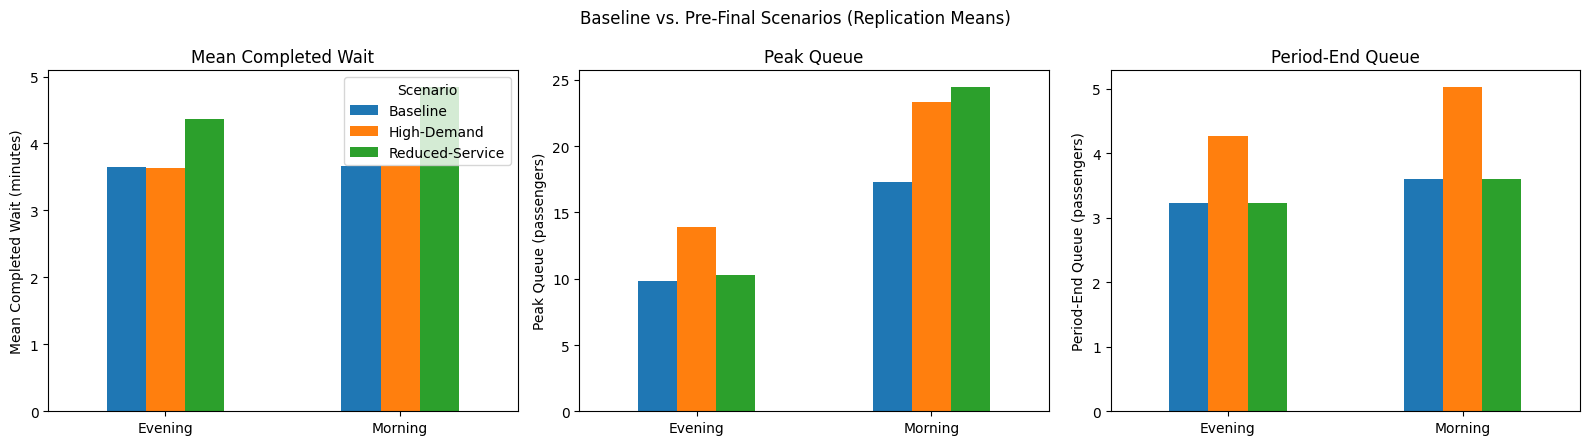

In [35]:
plt.style.use("default")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric, ylabel in zip(
    axes,
    ["Mean Completed Wait", "Peak Queue", "Period-End Queue"],
    ["Mean Completed Wait (minutes)", "Peak Queue (passengers)", "Period-End Queue (passengers)"]
):
    pivot = scenario_summary.pivot(index="Period", columns="Scenario", values=metric)
    pivot = pivot[["Baseline", "High-Demand", "Reduced-Service"]]
    pivot.plot(kind="bar", ax=ax, legend=(ax is axes[0]))
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Baseline vs. Pre-Final Scenarios (Replication Means)")
fig.tight_layout()

fig.savefig(figures_dir / "07_scenario_comparison_mean_wait_peak_queue_period_end.png", dpi=150)
plt.show()


## 20. Stop-Level Results (new — kept instead of discarded)

The simulation already produces per-stop waiting, queue, and occupancy detail; the first draft discarded it after computing period-level totals. This section keeps the per-stop breakdown and summarizes it (mean across replications) by Scenario, Period, and Stop Sequence, to show where queue pressure concentrates across the five selected stops.


In [36]:
all_stop_level_results = pd.concat(
    [baseline_stop_df, high_demand_stop_df, reduced_service_stop_df],
    ignore_index=True
)

stop_level_summary = (
    all_stop_level_results
    .groupby(["Scenario", "Period", "Stop Sequence"])[
        ["Mean Wait", "P95 Wait", "Peak Queue", "Period-End Queue", "Final Backlog"]
    ]
    .mean()
    .round(3)
    .reset_index()
)

stop_level_summary


,Scenario,Period,Stop Sequence,Mean Wait,P95 Wait,Peak Queue,Period-End Queue,Final Backlog
0,Baseline,Evening,6,3.327,6.968,7.467,2.067,2.067
1,Baseline,Evening,7,3.380,6.878,2.600,0.333,0.333
2,Baseline,Evening,8,3.656,8.073,2.200,0.333,0.333
3,Baseline,Evening,9,3.504,7.566,2.600,0.233,0.233
4,Baseline,Evening,10,4.222,11.613,9.667,0.267,0.267
5,Baseline,Morning,6,3.449,8.321,7.300,2.167,2.167
6,Baseline,Morning,7,3.583,7.893,2.333,0.200,0.000
7,Baseline,Morning,8,3.693,7.603,1.800,0.200,0.000
8,Baseline,Morning,9,3.685,8.625,2.833,0.200,0.000
9,Baseline,Morning,10,3.733,9.415,17.267,0.833,0.000


## 21. Save Handoff Outputs

In [37]:
# --- Scenario inputs / configuration ---
high_demand_demand.to_csv(
    processed_dir / "M66_HighDemand_Demand_Table.csv", index=False
)

additional_demand.to_csv(
    processed_dir / "M66_HighDemand_Additional_Demand.csv", index=False
)

scenario_config.to_csv(
    tables_dir / "scenario_configuration_parameters.csv", index=False
)

hourly_trip_counts_with_total.to_csv(
    tables_dir / "scenario_hourly_trip_counts.csv", index=False
)

# --- Reduced-Service reference schedule and removal documentation ---
reduced_service_plan.to_csv(
    processed_dir / "M66_ReducedService_Service_Plan.csv", index=False
)

removed_trips_df.to_csv(
    processed_dir / "M66_ReducedService_Removed_Trips.csv", index=False
)

removal_validation_df.to_csv(
    tables_dir / "scenario_reducedservice_removal_validation.csv", index=False
)

reference_service_plan = reduced_study_stop_times[
    ["trip_id", "stop_sequence", "arrival_time", "arrival_minutes"]
].merge(
    reduced_trip_initial_occupancy[["trip_id", "Hour", "Period"]],
    on="trip_id",
    how="left"
).sort_values(["Hour", "trip_id", "stop_sequence"]).reset_index(drop=True)

reference_service_plan.to_csv(
    processed_dir / "M66_ReducedService_Reference_Schedule.csv", index=False
)

# --- Passenger streams ---
# Only High-Demand's combined (Baseline + Additional) stream is genuinely new
# and is saved here. Per Requirement 19, Reduced-Service and the Baseline QA
# re-run reuse the exact same passengers/seeds as the official
# M66_Master_Passenger_Streams_30_Replications.csv and M66_Replication_Seeds.csv
# already in the repository, so no renamed duplicate copies of those two
# files are written.
high_demand_master_streams.to_csv(
    processed_dir / "M66_HighDemand_Master_Passenger_Streams.csv",
    index=False
)

# --- Simulation results (Baseline-compatible column format + Scenario column,
#     Replication/Seed/Period preserved for Sofi's paired GA comparison) ---
high_demand_results_df.to_csv(
    processed_dir / "M66_HighDemand_Results.csv", index=False
)

reduced_service_results_df.to_csv(
    processed_dir / "M66_ReducedService_Results.csv", index=False
)

all_scenario_results.to_csv(
    tables_dir / "scenario_vs_baseline_all_replications.csv", index=False
)

scenario_summary.to_csv(
    tables_dir / "scenario_vs_baseline_summary.csv", index=False
)

# --- Stop-level results ---
high_demand_stop_df.to_csv(
    processed_dir / "M66_HighDemand_StopLevel_Results.csv", index=False
)

reduced_service_stop_df.to_csv(
    processed_dir / "M66_ReducedService_StopLevel_Results.csv", index=False
)

stop_level_summary.to_csv(
    tables_dir / "scenario_stop_level_summary.csv", index=False
)

# --- Precision checks (saved even when 30 replications already pass) ---
high_demand_precision_df.to_csv(
    processed_dir / "M66_HighDemand_Precision_Check.csv", index=False
)

reduced_service_precision_df.to_csv(
    processed_dir / "M66_ReducedService_Precision_Check.csv", index=False
)

# --- Validation evidence ---
validation_summary_df.to_csv(
    tables_dir / "scenario_validation_summary.csv", index=False
)

print("All High-Demand and Reduced-Service handoff outputs saved.")


All High-Demand and Reduced-Service handoff outputs saved.


## 22. Changelog — What Changed in This Revision

Addressing the group's review of the first draft:

1. **Reduced-Service trip-removal rule** — replaced the median-position rule with the Midterm-required closest-to-hour-midpoint rule (earlier trip on ties). Reduced-Service was fully rerun under the new rule; all outputs in this notebook reflect it.
2. **High-Demand passenger streams** — Baseline passengers are now preserved exactly (same code, same seed) and only the additional passengers needed for +40% are newly generated with a distinct deterministic sub-stream, instead of regenerating the whole stream (Sections 3, 10).
3. **Replication precision check** — added for both scenarios: starts at 30 replications, checks the same 95% CI rule as Baseline, and extends by 10 (up to 50) if not met; the check is saved regardless of outcome (Sections 12–16, 21).
4. **Waiting-time and bus-occupancy validation** — added explicit non-negative-wait and occupancy-in-range checks and validation evidence table (Section 17).
5. **Stronger Reduced-Service removal validation** — added independent recheck of trip selection, tie-break behavior, full 5-stop removal, and the 38/39 totals (Section 6).
6. **Period-End Queue** — added to the main scenario comparison/summary table (Section 19).
7. **Stop-level results** — kept and summarized instead of discarded after each run (Sections 9, 20).
8. **Reduced-Service GA budget wording** — clarified that the 38/39 totals are a redistributable budget, not a fixed per-hour -1 constraint (Sections 18, 22 below).
9. **Paired-comparison identifiers** — confirmed Replication, Seed, and Period are preserved in every exported results table (Sections 21).
10. **Event-order wording** — corrected "boarding-before-alighting" to "alighting-before-boarding," matching the code (Section 9).
11. **Duplicate Baseline files** — stopped saving renamed copies of the official Baseline passenger-stream and seed files; the existing `M66_Master_Passenger_Streams_30_Replications.csv` and `M66_Replication_Seeds.csv` remain the single source of truth (Section 21).

What did **not** change (confirmed correct in review): the +40% demand calculation itself, the Baseline demand source, the Reduced-Service 43→38 / 44→39 trip totals, the initial-occupancy and alighting recalculation approach for Reduced-Service, reuse of Baseline passenger streams for Reduced-Service, reuse of the single discrete-event engine across scenarios, the 60-passenger capacity / FIFO / GTFS reference / bus-before-passenger tie rule, and the final-backlog logic.


## 23. Scope Boundary and Notes for the Group

- This notebook does **not** implement or change any GA/optimization logic. That component belongs to Sofi.
- The Combined scenario (High-Demand + Reduced-Service together) is **not** implemented here — it is listed as a separate planned item in the README and is out of scope for this handoff.
- **Assumption to confirm with the group:** upstream starting occupancy (Section 7) is derived from a separate upstream dataset and was intentionally left unchanged under High-Demand — confirmed correct in review, but flagged here again since it is a modeling decision the Combined scenario will also need to make explicitly.
- **For Sofi's GA integration:** the Reduced-Service reference has `Morning 38 / Evening 39` total trips (`scenario_configuration_parameters.csv`). These are **service budgets** for the GA to redistribute across the 5 hours of each period — the GA is **not** required to keep exactly one fewer trip in every individual hour. The per-hour `-1` reduction (`scenario_hourly_trip_counts.csv`) is only the *non-optimized reference schedule* used to generate this notebook's Reduced-Service simulation results, not a constraint on the optimizer's search space.
- Every exported results table (`M66_HighDemand_Results.csv`, `M66_ReducedService_Results.csv`, `scenario_vs_baseline_all_replications.csv`, and both stop-level results files) keeps `Replication`, `Seed`, and `Period` so Sofi's GA outputs can be paired against these reference results and 95% confidence intervals computed on the paired differences, the same way the baseline notebook already does for GTFS-vs-optimized comparisons.
- Per the team's branching plan, this work stays on `feature/prefinal-scenarios` and is not merged into `main` yet. If GA integration needs these scenario outputs, please branch a separate integration branch from `feature/prefinal-scenarios` rather than committing directly here.


In [38]:
# TECHNICAL DOCUMENTATION USED (Pre-Final scenario additions)
#
# MTA Bus Stop Level Ridership:
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS:
# https://www.mta.info/developers
#
# GTFS Schedule Reference:
# https://gtfs.org/documentation/schedule/reference/
#
# pandas documentation (groupby, sort_values, merge):
# https://pandas.pydata.org/docs/
#
# NumPy documentation (floor, random Generator, SeedSequence, tuple entropy):
# https://numpy.org/doc/
#
# Python heapq documentation:
# https://docs.python.org/3/library/heapq.html
#
# Matplotlib documentation:
# https://matplotlib.org/stable/
#
# MAIN METHOD SOURCES USED IN THIS NOTEBOOK
#
# Kieu, L. M., & Cai, C. (2018). Stochastic collective model of public
# transport passenger arrival process. IET Intelligent Transport Systems.
# https://doi.org/10.1049/iet-its.2018.0085
# Used again here (same as Baseline) to justify keeping the within-hour
# arrival-time sampling method identical between scenarios, and only
# varying the fixed hourly passenger count / additional passenger count.
#
# Currie, G., & Wallis, I. (2008). Effective ways to grow urban bus markets
# - a synthesis of evidence. Journal of Transport Geography, 16(6), 419-429.
# https://doi.org/10.1016/j.jtrangeo.2008.04.007
# Discusses demand-growth scenario analysis as a standard sensitivity-testing
# approach for bus service planning; used to support scaling representative
# demand by a fixed percentage as a deterministic high-demand stress test.
#
# El-Geneidy, A., Horning, J., & Krizek, K. J. (2011). Analyzing transit
# service reliability using detailed data from automatic vehicular locator
# systems. Journal of Transport Geography, 19(4), 853-863.
# https://doi.org/10.1016/j.jtrangeo.2010.10.005
# Discusses the passenger-waiting-time impact of missed/reduced scheduled
# trips; used to support the Reduced-Service scenario's trip-removal design
# and its expected effect on completed waiting time.
#
# Law, A. M. (2024). Simulation Modeling and Analysis (6th ed.). McGraw Hill.
# Same reference already cited in the baseline notebook's own precision
# check; used again here for the 95% confidence-interval replication
# precision rule applied to both scenarios (Section 12).
#
# CODE ADAPTATION NOTE
# No third-party GitHub repository code was adapted for this notebook.
# All scenario logic in Sections 3, 5, 6, 9, 10, 12, 13, 17, and 20 was
# written for this handoff, generalizing or extending functions already
# present in m66_baseline_simulation.ipynb (see each section's markdown cell
# for exactly what was reused unmodified vs. generalized vs. extended).
